# Import Libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor ,AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR


from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
from sklearn.model_selection import train_test_split , GridSearchCV , KFold , cross_val_score
from sklearn.preprocessing import RobustScaler , OneHotEncoder
from category_encoders import TargetEncoder

# Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/burakaltunda/players-fifa23/players_fifa23.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 90 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 18539 non-null  int64  
 1   Name               18539 non-null  object 
 2   FullName           18539 non-null  object 
 3   Age                18539 non-null  int64  
 4   Height             18539 non-null  int64  
 5   Weight             18539 non-null  int64  
 6   PhotoUrl           18539 non-null  object 
 7   Nationality        18539 non-null  object 
 8   Overall            18539 non-null  int64  
 9   Potential          18539 non-null  int64  
 10  Growth             18539 non-null  int64  
 11  TotalStats         18539 non-null  int64  
 12  BaseStats          18539 non-null  int64  
 13  Positions          18539 non-null  object 
 14  BestPosition       18539 non-null  object 
 15  Club               18539 non-null  object 
 16  ValueEUR           185

In [3]:
df.columns[33]

'PaceTotal'

# EDA + Feature Selection

In [4]:
df.head(10)

,ID,Name,FullName,Age,Height,Weight,PhotoUrl,Nationality,Overall,Potential,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
0,158023,L. Messi,Lionel Messi,35,169,67,https://cdn.sofifa.net/players/158/023/23_60.png,Argentina,91,91,...,91,88,91,67,66,67,62,53,62,22
1,165153,K. Benzema,Karim Benzema,34,185,81,https://cdn.sofifa.net/players/165/153/23_60.png,France,91,91,...,89,84,89,67,67,67,63,58,63,21
2,188545,R. Lewandowski,Robert Lewandowski,33,185,81,https://cdn.sofifa.net/players/188/545/23_60.png,Poland,91,91,...,86,83,86,67,69,67,64,63,64,22
3,192985,K. De Bruyne,Kevin De Bruyne,31,181,70,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,91,91,...,91,91,91,82,82,82,78,72,78,24
4,231747,K. Mbappé,Kylian Mbappé,23,182,73,https://cdn.sofifa.net/players/231/747/23_60.png,France,91,95,...,92,84,92,70,66,70,66,57,66,21
5,209331,M. Salah,Mohamed Salah,30,175,71,https://cdn.sofifa.net/players/209/331/23_60.png,Egypt,90,90,...,90,85,90,74,71,74,70,61,70,25
6,192119,T. Courtois,Thibaut Courtois,30,199,96,https://cdn.sofifa.net/players/192/119/23_60.png,Belgium,90,91,...,34,35,34,32,34,32,32,32,32,90
7,167495,M. Neuer,Manuel Neuer,36,193,93,https://cdn.sofifa.net/players/167/495/23_60.png,Germany,90,90,...,47,53,47,39,46,39,38,37,38,90
8,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,37,187,83,https://cdn.sofifa.net/players/020/801/23_60.png,Portugal,90,90,...,87,81,87,65,62,65,61,56,61,23
9,203376,V. van Dijk,Virgil van Dijk,30,193,92,https://cdn.sofifa.net/players/203/376/23_60.png,Netherlands,90,90,...,73,79,73,83,88,83,85,90,85,23


In [5]:
df.isnull().sum().sort_values(ascending = False)

NationalPosition    17722
NationalNumber      17722
ClubNumber             92
ClubPosition           92
ContractUntil          92
                    ...  
RWBRating               0
LBRating                0
CBRating                0
RBRating                0
GKRating                0
Length: 90, dtype: int64

In [6]:
# ID Name FullName PhotoUrl Potential ClubNumber ClubJoined NationalPosition NationalNumber WageEUR

In [7]:
delete_cols_1 = ["ID","Name","FullName","PhotoUrl","Potential","ClubNumber","ClubJoined","NationalPosition","NationalNumber"]
delete_cols_2 = df.iloc[:,33:90]

In [8]:
delete_cols_2

,PaceTotal,ShootingTotal,PassingTotal,DribblingTotal,DefendingTotal,PhysicalityTotal,Crossing,Finishing,HeadingAccuracy,ShortPassing,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
0,81,89,90,94,34,64,84,90,70,91,...,91,88,91,67,66,67,62,53,62,22
1,80,88,83,87,39,78,75,92,90,89,...,89,84,89,67,67,67,63,58,63,21
2,75,91,79,86,44,83,71,94,91,84,...,86,83,86,67,69,67,64,63,64,22
3,74,88,93,87,64,77,94,85,55,93,...,91,91,91,82,82,82,78,72,78,24
4,97,89,80,92,36,76,78,93,72,85,...,92,84,92,70,66,70,66,57,66,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18534,68,48,43,51,31,33,40,49,30,42,...,50,44,50,41,38,41,40,36,40,15
18535,55,37,41,47,48,39,34,33,44,46,...,45,45,45,47,48,47,49,49,49,15
18536,64,40,49,52,37,35,41,36,42,54,...,52,49,52,46,44,46,46,42,46,17
18537,52,24,25,32,52,41,21,20,41,25,...,33,33,33,44,42,44,47,49,47,15


In [9]:
df.drop(delete_cols_1 , inplace = True , axis=1)
df.drop(delete_cols_2 , inplace = True , axis=1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                18539 non-null  int64  
 1   Height             18539 non-null  int64  
 2   Weight             18539 non-null  int64  
 3   Nationality        18539 non-null  object 
 4   Overall            18539 non-null  int64  
 5   Growth             18539 non-null  int64  
 6   TotalStats         18539 non-null  int64  
 7   BaseStats          18539 non-null  int64  
 8   Positions          18539 non-null  object 
 9   BestPosition       18539 non-null  object 
 10  Club               18539 non-null  object 
 11  ValueEUR           18539 non-null  int64  
 12  WageEUR            18539 non-null  int64  
 13  ReleaseClause      18539 non-null  int64  
 14  ClubPosition       18447 non-null  object 
 15  ContractUntil      18447 non-null  float64
 16  OnLoad             185

In [11]:
numeric_cols = df.select_dtypes(include=["number"])
print(numeric_cols)

       Age  Height  Weight  Overall  Growth  TotalStats  BaseStats   ValueEUR  \
0       35     169      67       91       0        2190        452   54000000   
1       34     185      81       91       0        2147        455   64000000   
2       33     185      81       91       0        2205        458   84000000   
3       31     181      70       91       0        2303        483  107500000   
4       23     182      73       91       4        2177        470  190500000   
...    ...     ...     ...      ...     ...         ...        ...        ...   
18534   21     174      68       47       9        1287        274     110000   
18535   17     175      60       47      10        1289        267      90000   
18536   18     170      65       47      20        1333        277     130000   
18537   17     178      65       47      14        1113        226     100000   
18538   25     176      66       47       3        1277        269      60000   

       WageEUR  ReleaseClau

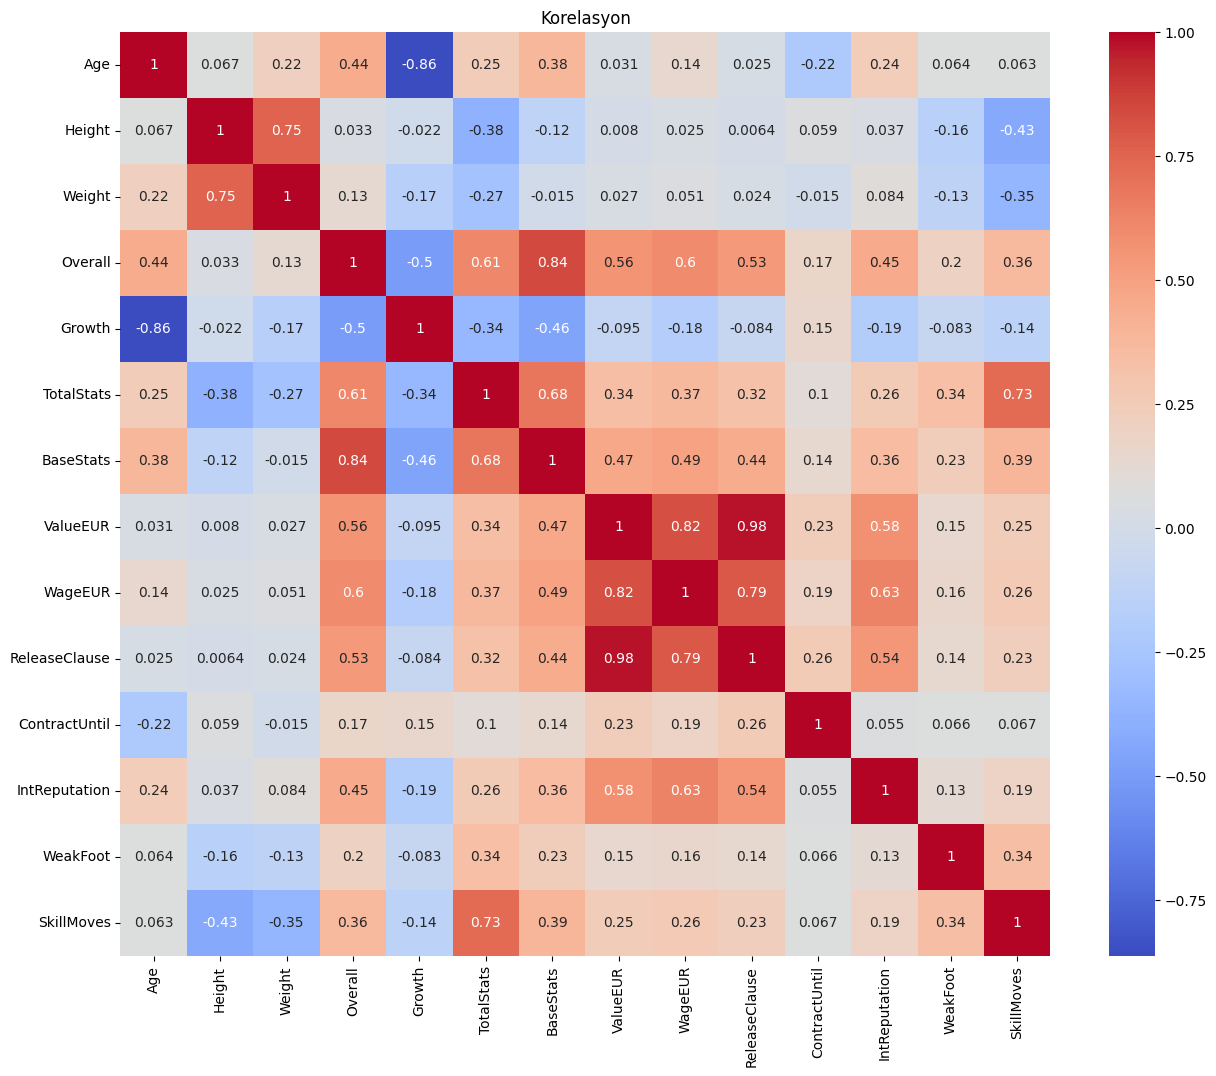

In [12]:
corr = numeric_cols.corr()

plt.figure(figsize=(15,12))
sns.heatmap (corr , cmap="coolwarm" , annot=True)
plt.title("Korelasyon")
plt.show()

In [13]:
df.drop("ReleaseClause" , inplace = True , axis = 1)

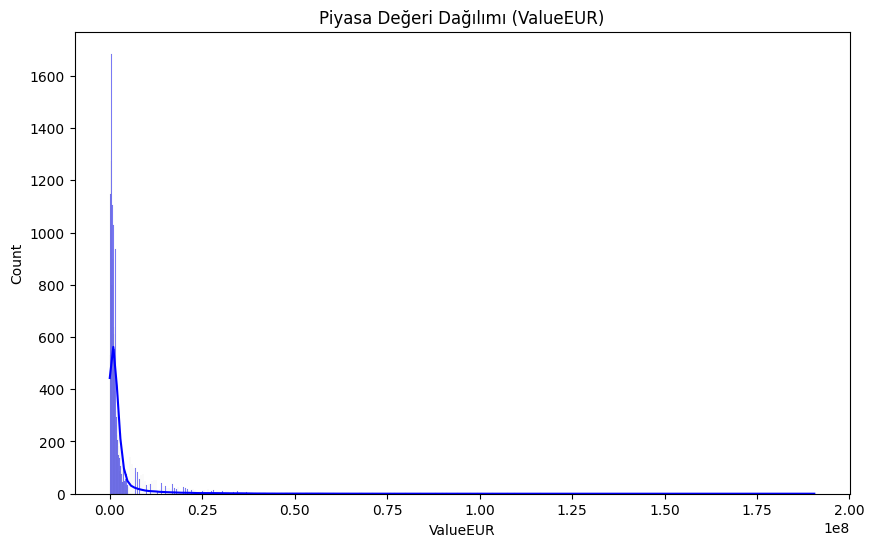

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['ValueEUR'], kde=True,color='blue')
plt.title('Piyasa Değeri Dağılımı (ValueEUR)')
plt.show()

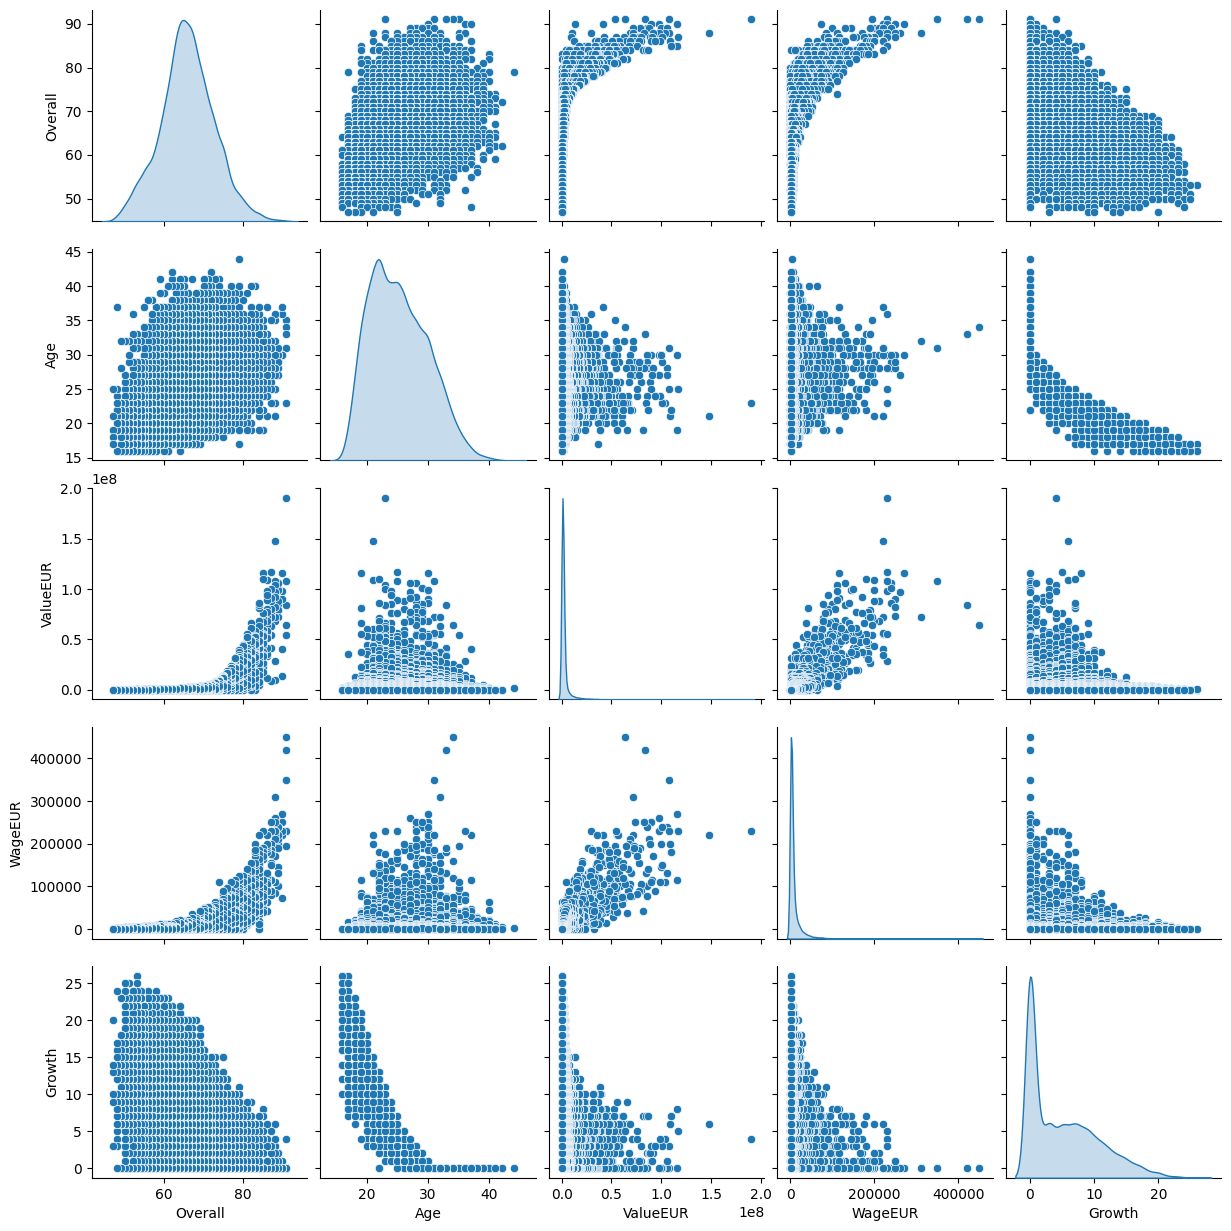

In [15]:
important_cols = ['Overall', 'Age', 'ValueEUR', 'WageEUR', 'Growth']
sns.pairplot(df[important_cols], diag_kind='kde')
plt.show()

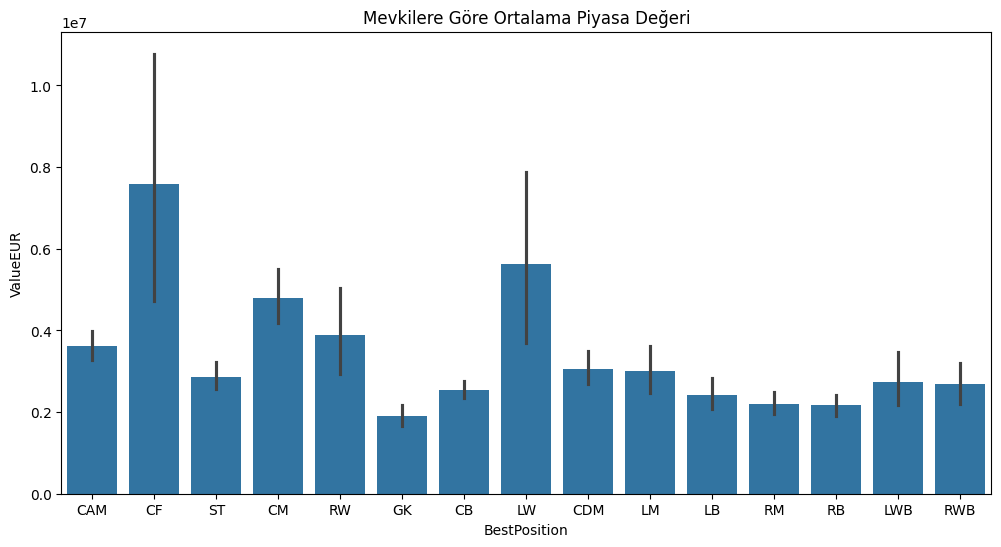

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(x='BestPosition', y='ValueEUR', data=df)
plt.title('Mevkilere Göre Ortalama Piyasa Değeri')
plt.show()

In [17]:
cat_cols = df.select_dtypes(include=["object"])
cat_cols

,Nationality,Positions,BestPosition,Club,ClubPosition,NationalTeam,PreferredFoot,AttackingWorkRate,DefensiveWorkRate
0,Argentina,RW,CAM,Paris Saint-Germain,RW,Argentina,Left,Low,Low
1,France,"CF,ST",CF,Real Madrid CF,CF,France,Right,Medium,Medium
2,Poland,ST,ST,FC Barcelona,ST,Poland,Right,High,Medium
3,Belgium,"CM,CAM",CM,Manchester City,CM,Belgium,Right,High,High
4,France,"ST,LW",ST,Paris Saint-Germain,ST,France,Right,High,Low
...,...,...,...,...,...,...,...,...,...
18534,Republic of Ireland,"ST,RM",CAM,Sligo Rovers,RES,Not in team,Right,Medium,Medium
18535,China PR,CDM,CDM,Guangzhou FC,SUB,Not in team,Right,Medium,Medium
18536,Northern Ireland,CM,RM,Derry City,SUB,Not in team,Right,High,Medium
18537,Republic of Ireland,CB,CB,Derry City,SUB,Not in team,Right,Medium,Medium


In [18]:
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} farklı değer ")

Nationality: 160 farklı değer 
Positions: 693 farklı değer 
BestPosition: 15 farklı değer 
Club: 679 farklı değer 
ClubPosition: 19 farklı değer 
NationalTeam: 36 farklı değer 
PreferredFoot: 2 farklı değer 
AttackingWorkRate: 3 farklı değer 
DefensiveWorkRate: 3 farklı değer 


# Train Test Split

In [19]:
X = df.drop("ValueEUR",axis = 1)
y = np.log1p(df["ValueEUR"])

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 ,random_state=42)

# Missing Values

In [20]:
contract_missing = X_train[X_train["ContractUntil"].isnull()]

print(len(contract_missing))

contract_missing[["Club", "Nationality", "Age" , "Overall","ContractUntil"]].head(50)

67


,Club,Nationality,Age,Overall,ContractUntil
9282,Free agent,Qatar,24,66,NaN
18043,Free agent,New Zealand,28,52,NaN
1188,Free agent,Mexico,29,76,NaN
1233,Free agent,Mexico,25,76,NaN
3336,Free agent,New Zealand,33,72,NaN
10424,Free agent,Northern Ireland,34,65,NaN
438,Free agent,Czech Republic,33,80,NaN
2952,Free agent,Sweden,29,72,NaN
10504,Free agent,New Zealand,23,65,NaN
10707,Free agent,Qatar,30,65,NaN


In [21]:
club_missing = X_train[X_train['ClubPosition'].isnull()]

print(len(club_missing))

club_missing[['Club', 'Nationality', 'Age' , "Overall","ClubPosition"]].head(50)

67


,Club,Nationality,Age,Overall,ClubPosition
9282,Free agent,Qatar,24,66,NaN
18043,Free agent,New Zealand,28,52,NaN
1188,Free agent,Mexico,29,76,NaN
1233,Free agent,Mexico,25,76,NaN
3336,Free agent,New Zealand,33,72,NaN
10424,Free agent,Northern Ireland,34,65,NaN
438,Free agent,Czech Republic,33,80,NaN
2952,Free agent,Sweden,29,72,NaN
10504,Free agent,New Zealand,23,65,NaN
10707,Free agent,Qatar,30,65,NaN


In [22]:
X_train['ContractUntil'] = X_train['ContractUntil'].fillna(2022)
X_test['ContractUntil'] = X_test['ContractUntil'].fillna(2022)

X_train['ClubPosition'] = X_train['ClubPosition'].fillna('FreeAgent')
X_test['ClubPosition'] = X_test['ClubPosition'].fillna('FreeAgent')

print(X_train.isnull().sum().sort_values(ascending=False))
print(X_test.isnull().sum().sort_values(ascending=False))

Age                  0
Height               0
Weight               0
Nationality          0
Overall              0
Growth               0
TotalStats           0
BaseStats            0
Positions            0
BestPosition         0
Club                 0
WageEUR              0
ClubPosition         0
ContractUntil        0
OnLoad               0
NationalTeam         0
PreferredFoot        0
IntReputation        0
WeakFoot             0
SkillMoves           0
AttackingWorkRate    0
DefensiveWorkRate    0
dtype: int64
Age                  0
Height               0
Weight               0
Nationality          0
Overall              0
Growth               0
TotalStats           0
BaseStats            0
Positions            0
BestPosition         0
Club                 0
WageEUR              0
ClubPosition         0
ContractUntil        0
OnLoad               0
NationalTeam         0
PreferredFoot        0
IntReputation        0
WeakFoot             0
SkillMoves           0
AttackingWorkRate    

# Feature Encoding

In [23]:
# ManuelMapping --> DefensiveWorkRate , AttackingWorkRate , PreferredFoot , NationalTeam ,Positions
# OHE --> BestPosition , ClubPosition 
# TargetEncoding --> Nationality , Club

## Manuel Mapping

In [24]:
manuel_mapping = {"Low":0,"Medium":1,"High":2}
X_train["DefensiveWorkRate"] = X_train['DefensiveWorkRate'].map(manuel_mapping)
X_test["DefensiveWorkRate"] = X_test['DefensiveWorkRate'].map(manuel_mapping)

X_train["AttackingWorkRate"] = X_train['AttackingWorkRate'].map(manuel_mapping)
X_test["AttackingWorkRate"] = X_test['AttackingWorkRate'].map(manuel_mapping)

mapping = ["DefensiveWorkRate" ,"AttackingWorkRate"]
print(X_train[mapping])
print(X_test[mapping])

       DefensiveWorkRate  AttackingWorkRate
1197                   2                  0
4209                   0                  1
6909                   2                  1
5123                   0                  2
5864                   2                  1
...                  ...                ...
11284                  2                  0
11964                  1                  1
5390                   2                  0
860                    1                  2
15795                  1                  1

[12977 rows x 2 columns]
       DefensiveWorkRate  AttackingWorkRate
10157                  1                  1
3617                   2                  1
4894                   1                  2
2315                   1                  1
2177                   1                  2
...                  ...                ...
7453                   2                  1
6735                   2                  1
15730                  1                  1
465   

In [25]:
foot_map = {"Right":0 ,"Left":1}
X_train["PreferredFoot"] = X_train["PreferredFoot"].map(foot_map) 
X_test["PreferredFoot"] = X_test["PreferredFoot"].map(foot_map) 
print(X_train["PreferredFoot"])
print(X_test["PreferredFoot"])

1197     1
4209     1
6909     0
5123     0
5864     0
        ..
11284    0
11964    1
5390     0
860      0
15795    0
Name: PreferredFoot, Length: 12977, dtype: int64
10157    1
3617     1
4894     1
2315     1
2177     0
        ..
7453     1
6735     0
15730    0
465      1
10054    0
Name: PreferredFoot, Length: 5562, dtype: int64


In [26]:
X_train["NationalTeam"].value_counts()

NationalTeam
Not in team            12409
Czech Republic            21
France                    19
Italy                     19
Ghana                     19
Scotland                  18
Republic of Ireland       18
New Zealand               18
Mexico                    18
Northern Ireland          18
Poland                    18
Denmark                   17
Netherlands               17
Germany                   17
Austria                   17
England                   17
United States             17
Canada                    17
Finland                   16
Morocco                   16
China PR                  16
Iceland                   16
Romania                   16
Sweden                    15
Belgium                   15
Wales                     15
Qatar                     15
Hungary                   15
Brazil                    15
Norway                    14
Portugal                  14
Spain                     14
Ukraine                   14
Australia                 13
C

In [27]:
def nationalTeam(df,col): 
    df[col] = df[col].apply(lambda x: 0 if x == "Not in team" else 1)
    return df

nationalTeam(X_train,"NationalTeam")
nationalTeam(X_test,"NationalTeam")

print(X_train["NationalTeam"])

1197     1
4209     0
6909     0
5123     0
5864     0
        ..
11284    0
11964    0
5390     0
860      0
15795    0
Name: NationalTeam, Length: 12977, dtype: int64


In [28]:
X_train['Positions'] = X_train['Positions'].apply(lambda x: len(x.split(',')))
X_test['Positions'] = X_test['Positions'].apply(lambda x: len(x.split(',')))

X_train["Positions"]

1197     1
4209     3
6909     2
5123     2
5864     1
        ..
11284    2
11964    2
5390     1
860      2
15795    2
Name: Positions, Length: 12977, dtype: int64

## OHE

In [29]:
ohe = OneHotEncoder(handle_unknown="ignore" , sparse_output = False , drop="first")
ohe_cols = ["BestPosition" , "ClubPosition"]

ohe_final_train = ohe.fit_transform(X_train[ohe_cols])
ohe_final_test  = ohe.transform(X_test[ohe_cols])

ohe_df_train = pd.DataFrame(ohe_final_train , columns = ohe.get_feature_names_out(ohe_cols) ,index = X_train.index )

ohe_df_test  = pd.DataFrame(ohe_final_test , columns = ohe.get_feature_names_out(ohe_cols) , index = X_test.index)

X_train = pd.concat([X_train.drop(ohe_cols , axis=1) , ohe_df_train] , axis = 1)
X_test  = pd.concat([X_test.drop(ohe_cols , axis=1) , ohe_df_test] , axis = 1)

In [30]:
X_train.columns
X_test.columns

Index(['Age', 'Height', 'Weight', 'Nationality', 'Overall', 'Growth',
       'TotalStats', 'BaseStats', 'Positions', 'Club', 'WageEUR',
       'ContractUntil', 'OnLoad', 'NationalTeam', 'PreferredFoot',
       'IntReputation', 'WeakFoot', 'SkillMoves', 'AttackingWorkRate',
       'DefensiveWorkRate', 'BestPosition_CB', 'BestPosition_CDM',
       'BestPosition_CF', 'BestPosition_CM', 'BestPosition_GK',
       'BestPosition_LB', 'BestPosition_LM', 'BestPosition_LW',
       'BestPosition_LWB', 'BestPosition_RB', 'BestPosition_RM',
       'BestPosition_RW', 'BestPosition_RWB', 'BestPosition_ST',
       'ClubPosition_CB', 'ClubPosition_CDM', 'ClubPosition_CF',
       'ClubPosition_CM', 'ClubPosition_FreeAgent', 'ClubPosition_GK',
       'ClubPosition_LB', 'ClubPosition_LF', 'ClubPosition_LM',
       'ClubPosition_LW', 'ClubPosition_LWB', 'ClubPosition_RB',
       'ClubPosition_RES', 'ClubPosition_RF', 'ClubPosition_RM',
       'ClubPosition_RW', 'ClubPosition_RWB', 'ClubPosition_ST',
      

## Target Encoding

In [31]:
target_cols = ["Nationality" , "Club"]
te = TargetEncoder(cols = target_cols , smoothing = 10)

X_train = te.fit_transform(X_train , y_train)
X_test  = te.transform(X_test)

In [32]:
X_train[target_cols]

,Nationality,Club
1197,13.620979,14.358532
4209,14.254307,13.588788
6909,14.332063,13.635784
5123,14.504148,14.148231
5864,13.924589,13.939582
...,...,...
11284,12.705452,13.571793
11964,13.846544,13.329308
5390,14.332063,13.812375
860,14.332063,14.562946


# Scaling

In [33]:
rs = RobustScaler()

X_train_scaled = rs.fit_transform(X_train)
X_test_scaled = rs.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train

,Age,Height,Weight,Nationality,Overall,Growth,TotalStats,BaseStats,Positions,Club,...,ClubPosition_LW,ClubPosition_LWB,ClubPosition_RB,ClubPosition_RES,ClubPosition_RF,ClubPosition_RM,ClubPosition_RW,ClubPosition_RWB,ClubPosition_ST,ClubPosition_SUB
0,0.625,0.555556,-0.2,-0.444614,1.250,-0.444444,0.034700,-0.111111,-1.0,1.157100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.625,-1.777778,-1.4,0.482848,0.625,-0.444444,0.492114,0.351852,1.0,-0.457856,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.500,0.000000,0.8,0.596715,0.250,-0.444444,0.211356,0.092593,0.0,-0.359257,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.125,-0.333333,-0.8,0.848722,0.500,0.222222,0.447950,0.444444,0.0,0.715878,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.250,0.888889,0.3,0.000000,0.375,0.444444,0.384858,0.648148,-1.0,0.278125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12972,0.375,0.111111,0.8,-1.785336,-0.250,-0.444444,0.003155,-0.055556,0.0,-0.493513,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12973,-0.250,-0.666667,-0.5,-0.114291,-0.375,0.222222,-0.053628,-0.092593,0.0,-1.002256,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12974,1.250,0.555556,1.0,0.596715,0.375,-0.444444,0.094637,0.018519,-1.0,0.011239,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12975,0.500,-0.666667,-0.2,0.596715,1.375,-0.444444,1.246057,1.333333,0.0,1.585969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
y_train

1197     15.607270
4209     14.403298
6909     13.815512
5123     14.731802
5864     14.880222
           ...    
11284    13.171155
11964    13.458837
5390     12.834684
860      16.166886
15795    12.301387
Name: ValueEUR, Length: 12977, dtype: float64

# Modelling

In [35]:
print(X_train.isnull().sum())

Age                       0
Height                    0
Weight                    0
Nationality               0
Overall                   0
Growth                    0
TotalStats                0
BaseStats                 0
Positions                 0
Club                      0
WageEUR                   0
ContractUntil             0
OnLoad                    0
NationalTeam              0
PreferredFoot             0
IntReputation             0
WeakFoot                  0
SkillMoves                0
AttackingWorkRate         0
DefensiveWorkRate         0
BestPosition_CB           0
BestPosition_CDM          0
BestPosition_CF           0
BestPosition_CM           0
BestPosition_GK           0
BestPosition_LB           0
BestPosition_LM           0
BestPosition_LW           0
BestPosition_LWB          0
BestPosition_RB           0
BestPosition_RM           0
BestPosition_RW           0
BestPosition_RWB          0
BestPosition_ST           0
ClubPosition_CB           0
ClubPosition_CDM    

## Linear Regression

In [36]:
lr_reg = LinearRegression()

lr_reg.fit(X_train, y_train)

y_pred_lr = lr_reg.predict(X_test)

real_y_test = np.expm1(y_test)
real_y_pred = np.expm1(y_pred_lr)

r2_lr = r2_score(real_y_test, real_y_pred)
mae_lr = mean_absolute_error(real_y_test, real_y_pred)
rmse_lr = np.sqrt(mean_squared_error(real_y_test, real_y_pred))

cv_scores = cross_val_score(lr_reg, X_train, y_train, cv=5, scoring='r2')

print("Linear Regression 5-Fold CV")
print(f"Her Bir Katın R2 Skoru: {cv_scores.round(4)}")
print(f"Ortalama R2 Skoru: {cv_scores.mean():.4f}")
print(f"Standart Sapma: {cv_scores.std():.4f}")
print("---------------------")
print("Linear Regression")
print(f"R2 Skoru: {r2_lr:.4f}")
print(f"MAE: {mae_lr:,.0f} EUR")
print(f"RMSE: {rmse_lr:,.0f} EUR")

Linear Regression 5-Fold CV
Her Bir Katın R2 Skoru: [0.9383 0.9    0.9464 0.9112 0.9596]
Ortalama R2 Skoru: 0.9311
Standart Sapma: 0.0222
---------------------
Linear Regression
R2 Skoru: 0.7079
MAE: 683,178 EUR
RMSE: 4,193,853 EUR


## Decision Tree

In [37]:
dt_reg = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [10, 20, 30, 40 ,50],          
    'min_samples_split': [2, 10, 20],         
    'min_samples_leaf': [1, 5, 10]           
}

grid_search_dt = GridSearchCV(estimator=dt_reg, 
                             param_grid=param_grid, 
                             cv=5, 
                             scoring='r2', 
                             n_jobs=-1, 
                             )

grid_search_dt.fit(X_train, y_train)


best_dt_model = grid_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test)

real_y_test = np.expm1(y_test)
real_y_pred_dt = np.expm1(y_pred_dt)


r2_dt = r2_score(real_y_test, real_y_pred_dt)
mae_dt = mean_absolute_error(real_y_test, real_y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(real_y_test, real_y_pred_dt))

print("EN İYİ PARAMETRELER")
print(grid_search_dt.best_params_)

print("DECISION TREE")
print(f"R2: {r2_dt:.4f}")
print(f"MAE: {mae_dt:,.0f} EUR")
print(f"RMSE: {rmse_dt:,.0f} EUR")

EN İYİ PARAMETRELER
{'max_depth': 40, 'min_samples_leaf': 1, 'min_samples_split': 2}
DECISION TREE
R2: 0.9268
MAE: 270,103 EUR
RMSE: 2,099,065 EUR


## Random Forest

In [38]:
rf_reg = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],          
    'max_depth': [10, 20],         
    'min_samples_split': [2, 5],          
    'max_features': ['sqrt', 'log2']      
}

grid_search_rf = GridSearchCV(estimator=rf_reg, 
                             param_grid=param_grid, 
                             cv=5, 
                             scoring='r2', 
                             n_jobs=-1, 
                             verbose=1)


grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

real_y_test = np.expm1(y_test)
real_y_pred_rf = np.expm1(y_pred_rf)

r2_rf = r2_score(real_y_test, real_y_pred_rf)
mae_rf = mean_absolute_error(real_y_test, real_y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(real_y_test, real_y_pred_rf))

print("EN İYİ PARAMETRELER")
print(grid_search_rf.best_params_)

print("RANDOM FOREST")
print(f"R2 Skoru: {r2_rf:.4f}")
print(f"MAE: {mae_rf:,.0f} EUR")
print(f"RMSE: {rmse_rf:,.0f} EUR")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
EN İYİ PARAMETRELER
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
RANDOM FOREST
R2 Skoru: 0.8181
MAE: 683,396 EUR
RMSE: 3,309,401 EUR


## KNN

In [39]:
knn_reg = KNeighborsRegressor()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'], 
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(estimator=knn_reg, 
                               param_grid=param_grid_knn, 
                               cv=5, 
                               scoring='r2', 
                               n_jobs=-1, 
                               verbose=1)


grid_search_knn.fit(X_train, y_train)

best_knn_model = grid_search_knn.best_estimator_
y_pred_knn = best_knn_model.predict(X_test)


real_y_test = np.expm1(y_test)
real_y_pred_knn = np.expm1(y_pred_knn)

r2_knn = r2_score(real_y_test, real_y_pred_knn)
mae_knn = mean_absolute_error(real_y_test, real_y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(real_y_test, real_y_pred_knn))

print("EN İYİ PARAMETRELER")
print(grid_search_knn.best_params_)

print("KNN PERFORMANSI")
print(f"R2 Skoru: {r2_knn:.4f}")
print(f"MAE: {mae_knn:,.0f} EUR")
print(f"RMSE: {rmse_knn:,.0f} EUR")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
EN İYİ PARAMETRELER
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
KNN PERFORMANSI
R2 Skoru: 0.7667
MAE: 991,351 EUR
RMSE: 3,748,222 EUR


## Adaboost

In [40]:
base_dt = DecisionTreeRegressor(max_depth=4 ,min_samples_leaf = 1, min_samples_split= 2)
ada_reg = AdaBoostRegressor(estimator=base_dt, random_state=42)

param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0 , 3.0],
    'loss': ['linear', 'square', 'exponential']
}

grid_search_ada = GridSearchCV(estimator=ada_reg, 
                               param_grid=param_grid_ada, 
                               cv=5, 
                               scoring='r2', 
                               n_jobs=-1, 
                               verbose=1)

grid_search_ada.fit(X_train, y_train)

best_ada_model = grid_search_ada.best_estimator_
y_pred_ada = best_ada_model.predict(X_test)

real_y_test = np.expm1(y_test)
real_y_pred_ada = np.expm1(y_pred_ada)

r2_ada = r2_score(real_y_test, real_y_pred_ada)
mae_ada = mean_absolute_error(real_y_test, real_y_pred_ada)
rmse_ada = np.sqrt(mean_squared_error(real_y_test, real_y_pred_ada))

print("PARAMETRELER")
print(grid_search_ada.best_params_)

print("ADABOOST")
print(f"R2 Skoru: {r2_ada:.4f}")
print(f"MAE: {mae_ada:,.0f} EUR")
print(f"RMSE: {rmse_ada:,.0f} EUR")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
PARAMETRELER
{'learning_rate': 1.0, 'loss': 'exponential', 'n_estimators': 100}
ADABOOST
R2 Skoru: 0.7970
MAE: 831,058 EUR
RMSE: 3,496,775 EUR


## SVM

In [41]:
svr_reg = SVR()

param_grid_svr = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf']
}

grid_search_svr = GridSearchCV(estimator=svr_reg, 
                               param_grid=param_grid_svr, 
                               cv=5, 
                               scoring='r2', 
                               n_jobs=-1, 
                               verbose=1)

grid_search_svr.fit(X_train, y_train)

best_svr_model = grid_search_svr.best_estimator_
y_pred_svr = best_svr_model.predict(X_test)

real_y_test = np.expm1(y_test)
real_y_pred_svr = np.expm1(y_pred_svr)

r2_svr = r2_score(real_y_test, real_y_pred_svr)
mae_svr = mean_absolute_error(real_y_test, real_y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(real_y_test, real_y_pred_svr))

print("PARAMETRELER")
print(grid_search_svr.best_params_)

print("SVR")
print(f"R2 Skoru: {r2_svr:.4f}")
print(f"MAE: {mae_svr:,.0f} EUR")
print(f"RMSE: {rmse_svr:,.0f} EUR")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
PARAMETRELER
{'C': 10, 'epsilon': 0.01, 'kernel': 'rbf'}
SVR
R2 Skoru: 0.7916
MAE: 493,679 EUR
RMSE: 3,542,768 EUR


# Results 

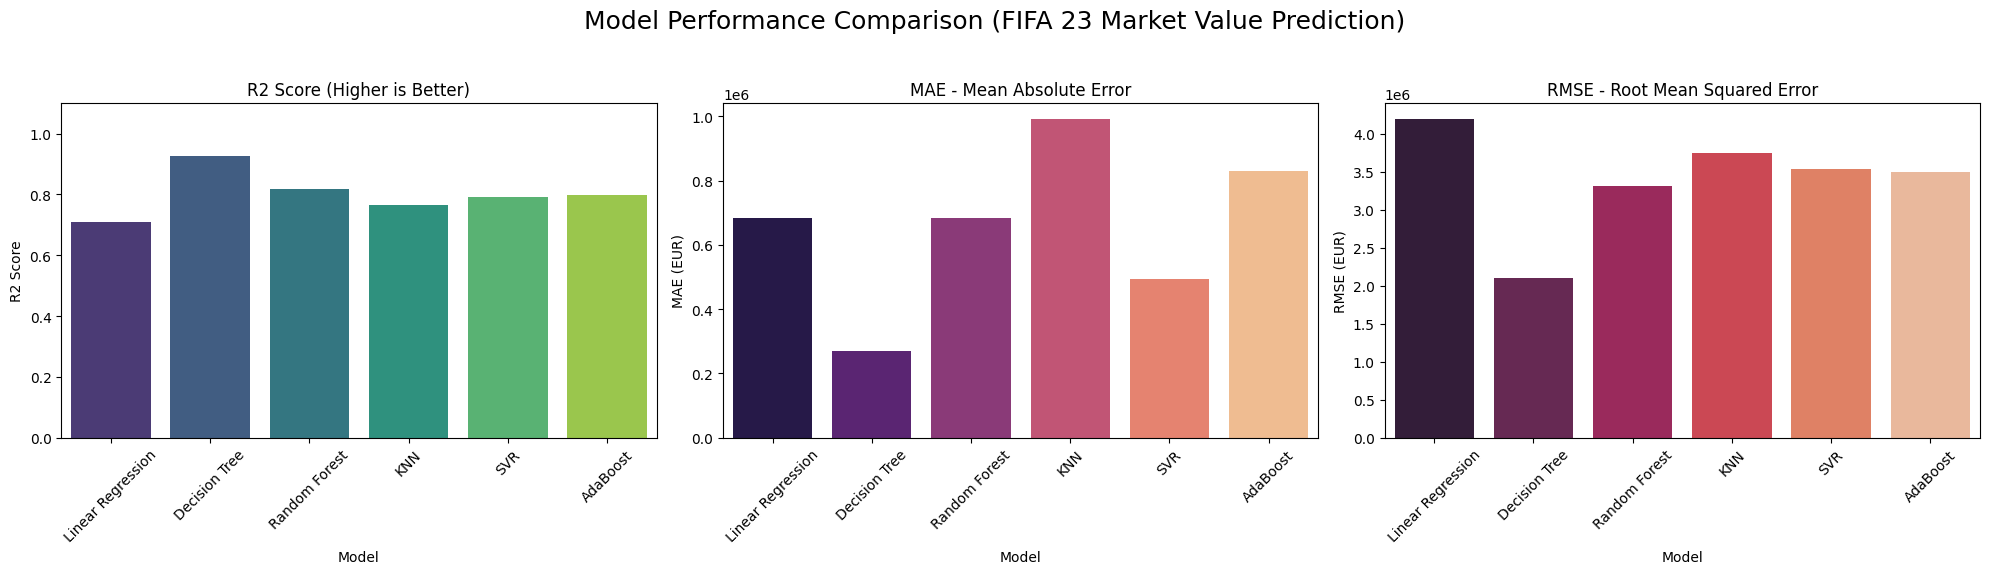

In [42]:
model_results = {
    'Model': ['Linear Regression', "Decision Tree",'Random Forest', 'KNN', 'SVR', 'AdaBoost'],
    'R2 Score': [r2_lr, r2_dt,r2_rf, r2_knn, r2_svr, r2_ada],
    'MAE (EUR)': [mae_lr, mae_dt,mae_rf, mae_knn, mae_svr, mae_ada],
    'RMSE (EUR)': [rmse_lr, rmse_dt,rmse_rf, rmse_knn, rmse_svr, rmse_ada]
}

results_df = pd.DataFrame(model_results)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison (FIFA 23 Market Value Prediction)', fontsize=18)

sns.barplot(x='Model', y='R2 Score', data=results_df, ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('R2 Score (Higher is Better)')
axes[0].set_ylim(0, 1.1)

sns.barplot(x='Model', y='MAE (EUR)', data=results_df, ax=axes[1], palette='magma', hue='Model', legend=False)
axes[1].set_title('MAE - Mean Absolute Error')

sns.barplot(x='Model', y='RMSE (EUR)', data=results_df, ax=axes[2], palette='rocket', hue='Model', legend=False)
axes[2].set_title('RMSE - Root Mean Squared Error')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

formatted_df = results_df.copy()
formatted_df['R2 Score'] = formatted_df['R2 Score'].map('{:.4f}'.format)
formatted_df['MAE (EUR)'] = formatted_df['MAE (EUR)'].map('{:,.0f}'.format)
formatted_df['RMSE (EUR)'] = formatted_df['RMSE (EUR)'].map('{:,.0f}'.format)

In [43]:
formatted_df = results_df.copy()
formatted_df['R2 Score'] = formatted_df['R2 Score'].map('{:.4f}'.format)
formatted_df['MAE (EUR)'] = formatted_df['MAE (EUR)'].map('{:,.0f}'.format)
formatted_df['RMSE (EUR)'] = formatted_df['RMSE (EUR)'].map('{:,.0f}'.format)

print(formatted_df.sort_values(by='R2 Score', ascending=False))

               Model R2 Score MAE (EUR) RMSE (EUR)
1      Decision Tree   0.9268   270,103  2,099,065
2      Random Forest   0.8181   683,396  3,309,401
5           AdaBoost   0.7970   831,058  3,496,775
4                SVR   0.7916   493,679  3,542,768
3                KNN   0.7667   991,351  3,748,222
0  Linear Regression   0.7079   683,178  4,193,853


## 